# Superstitious Behavior in RL Agents — Extended Study

This notebook extends the pilot case study into a more rigorous, multi-condition
experiment, built to address the gaps a journal reviewer would flag:

1. **Multi-seed statistics** — every condition is run across multiple random seeds
   and reported as mean +/- std, with formal significance tests (Mann-Whitney U /
   Kruskal-Wallis) and effect sizes (Cohen's d), instead of single anecdotal runs.
2. **All three reward schedules** from the operant-conditioning literature: fixed
   interval, variable interval, and random (probabilistic) — not just fixed interval.
3. **A ritual-length / ritual-strength metric**, in addition to action entropy —
   this measures whether a *specific* action reliably precedes reward, which is
   closer to what Skinner's pigeons actually did than overall entropy alone.
4. **Four algorithms**: Q-learning, DQN, PPO, A2C — spanning bootstrapped
   (Q-learning, DQN), Monte-Carlo/GAE-based (PPO), and synchronous
   actor-critic (A2C) credit assignment.
5. **A curiosity-driven exploration bonus**, tested on/off.

**Important honesty note on the curiosity module:** true prediction-error-based
curiosity (ICM / RND) needs an observation that *varies*, so the agent's internal
model can be "surprised" by it. Our environment is deliberately a single constant
state (that's what makes it a clean Skinner-box analogy for Q-learning). So instead
of RND, we implement a **count-based exploration bonus**
(`bonus = c / sqrt(visits(action) + 1)`), in the spirit of classic pseudo-count /
UCB-style intrinsic motivation. This is a legitimate, citable family of exploration
methods, but it is not literally RND/ICM — say so explicitly in your write-up.

**Scope note:** the environment remains the single-state "Skinner box" toy
environment from the pilot study (no richer/spatial environment was added here).

Run cells top to bottom in Colab. With the default settings (8 seeds, 15,000 steps
per run) the whole notebook takes roughly **15-20 minutes** end to end. Reduce
`N_SEEDS` or `TOTAL_STEPS` in the config cell for a quick smoke-test run first.
**Revision note (this version):** this notebook now also includes — a documented
table of the exact DQN hyperparameter overrides (Section 4), bootstrap 95% CIs and
Holm-Bonferroni-corrected p-values for every statistical test run anywhere in the
study (Section 7), epsilon-squared effect sizes for every Kruskal-Wallis test, an
interval-length sensitivity check for Q-learning at I=5/10/20 (Section 6, "Tier D"),
and a raw per-seed data export + repo-packaging step (Sections 8-9) so the
"available on request" line in the paper can become a real DOI link. Runtime is
correspondingly longer — the new Tier D adds roughly another third of Tier B's
Q-learning runtime.


In [1]:
!pip install stable-baselines3 gymnasium scipy pandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 4.8 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque, Counter

import gymnasium as gym
from gymnasium import spaces

from scipy.stats import mannwhitneyu, kruskal

# ---- Global configuration ----
N_SEEDS = 8            # seeds per condition. Reduce to 2-3 for a fast smoke test.
TOTAL_STEPS = 15000     # training steps per run
N_ACTIONS = 4
INTERVAL = 10           # mean steps between noncontingent rewards
WINDOW = 200            # trailing window size for entropy
LOG_EVERY = 300         # how often (in steps) to log entropy
RITUAL_TAIL = 30        # number of most-recent reward events used for ritual_strength

np.random.seed(0)

# ---- Added for this revision: significance/CI settings shared by every tier ----
ALPHA = 0.05            # significance threshold used throughout, pre- and post-correction
N_BOOT = 10000           # bootstrap resamples used for 95% CIs on group differences
CI_LEVEL = 0.95
BOOT_SEED = 12345        # fixed seed for the bootstrap RNG, so CIs are reproducible run-to-run


## 1. The Environment

Same core idea as the pilot: a single-state "Skinner box" with `N_ACTIONS` possible
actions. Extended to support:
- `schedule_type`: `"fixed"` (reward every `interval` steps), `"variable"` (reward
  after a randomly varying interval around the mean), `"random"` (reward each step
  with probability `1/interval`, i.e. no fixed clock at all — a memoryless schedule).
- `reward_mode`: `"noncontingent"` (the schedules above, reward is action-independent)
  or `"contingent"` (reward only for a specific `target_action` — the control).
- `curiosity_bonus`: optional count-based exploration bonus added on top of
  whatever extrinsic reward the schedule produces.

The `info` dict returned by `step()` always reports the **raw extrinsic reward**
separately from any curiosity bonus, so our behavioral metrics can track genuine
reward-timing events even when curiosity shaping is active.

In [3]:
class SkinnerBoxEnv(gym.Env):
    """
    Minimal Skinner-box RL environment with configurable reward schedule,
    reward contingency, and an optional count-based curiosity bonus.
    """
    metadata = {"render_modes": []}

    def __init__(self, n_actions=4, interval=10, episode_len=500,
                 reward_mode="noncontingent", schedule_type="fixed",
                 target_action=0, curiosity_bonus=False, curiosity_coef=0.5,
                 seed=None):
        super().__init__()
        self.n_actions = n_actions
        self.interval = interval
        self.episode_len = episode_len
        self.reward_mode = reward_mode
        self.schedule_type = schedule_type
        self.target_action = target_action
        self.curiosity_bonus = curiosity_bonus
        self.curiosity_coef = curiosity_coef

        self.action_space = spaces.Discrete(n_actions)
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32)

        # Separate RNG that drives the reward schedule (kept apart from any
        # exploration RNG the agent itself uses).
        self._schedule_rng = np.random.default_rng(seed)
        self._step_count = 0
        self._global_step = 0
        self._action_counts = np.zeros(n_actions)
        self._next_reward_step = self._draw_next_reward_step()

    def _draw_next_reward_step(self):
        if self.schedule_type == "fixed":
            return self._global_step + self.interval
        elif self.schedule_type == "variable":
            # Variable interval: next reward drawn uniformly around the mean interval.
            low = max(1, int(self.interval * 0.5))
            high = int(self.interval * 1.5) + 1
            return self._global_step + int(self._schedule_rng.integers(low, high))
        elif self.schedule_type == "random":
            return None  # handled per-step probabilistically instead
        else:
            raise ValueError(f"Unknown schedule_type: {self.schedule_type}")

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._step_count = 0
        obs = np.array([0.0], dtype=np.float32)
        return obs, {}

    def step(self, action):
        self._step_count += 1
        self._global_step += 1
        self._action_counts[action] += 1

        if self.reward_mode == "noncontingent":
            if self.schedule_type in ("fixed", "variable"):
                extrinsic = 1.0 if self._global_step >= self._next_reward_step else 0.0
                if extrinsic > 0:
                    self._next_reward_step = self._draw_next_reward_step()
            elif self.schedule_type == "random":
                extrinsic = 1.0 if self._schedule_rng.random() < (1.0 / self.interval) else 0.0
            else:
                raise ValueError(f"Unknown schedule_type: {self.schedule_type}")
        elif self.reward_mode == "contingent":
            extrinsic = 1.0 if action == self.target_action else 0.0
        else:
            raise ValueError(f"Unknown reward_mode: {self.reward_mode}")

        reward = extrinsic
        if self.curiosity_bonus:
            reward += self.curiosity_coef / np.sqrt(self._action_counts[action])

        terminated = False
        truncated = self._step_count >= self.episode_len
        obs = np.array([0.0], dtype=np.float32)
        # extrinsic_reward lets downstream code detect real reward events
        # even when a curiosity bonus is shaping the total reward.
        info = {"extrinsic_reward": extrinsic}
        return obs, reward, terminated, truncated, info

In [4]:
# Sanity check: each schedule should deliver ~200 rewards in 2000 random-action steps
for sched in ["fixed", "variable", "random"]:
    env = SkinnerBoxEnv(interval=10, schedule_type=sched, seed=0)
    obs, _ = env.reset(seed=0)
    n_reward = 0
    for _ in range(2000):
        a = env.action_space.sample()
        obs, r, term, trunc, info = env.step(a)
        if info["extrinsic_reward"] > 0:
            n_reward += 1
    print(f"{sched:>9s}: {n_reward} rewards in 2000 steps (expect ~200)")

    fixed: 200 rewards in 2000 steps (expect ~200)
 variable: 194 rewards in 2000 steps (expect ~200)
   random: 210 rewards in 2000 steps (expect ~200)


## 2. Behavioral Metrics

Two complementary metrics:

- **Action entropy** (as in the pilot): how spread-out vs. concentrated the recent
  action distribution is. Low entropy = the agent favors one action overall.
- **Ritual metrics** (new): computed only from the actions taken **at the moment
  reward was actually delivered** (`extrinsic_reward > 0`), not all actions. This is
  closer to Skinner's original phenomenon — it is not "does the agent favor one
  button overall," but "is there one specific action that keeps getting
  associated with reward delivery":
  - `ritual_strength`: over the most recent `RITUAL_TAIL` reward events, the
    fraction that share the single most common ("modal") action. 1.0 = every
    recent reward was preceded by the exact same action (a fully formed ritual).
  - `ritual_streak`: the longest run of *consecutive* reward events preceded by
    the identical action, across the whole training run.

In [5]:
def compute_entropy(action_window, n_actions):
    """Shannon entropy (bits) of the action distribution in a window of actions."""
    if len(action_window) == 0:
        return np.log2(n_actions)
    counts = np.bincount(action_window, minlength=n_actions)
    probs = counts / counts.sum()
    probs = probs[probs > 0]
    return float(-np.sum(probs * np.log2(probs)))


def ritual_metrics(action_log, tail=RITUAL_TAIL):
    """
    action_log: list of actions taken at each moment reward was delivered
    (in chronological order). Returns ritual_strength and ritual_streak.
    """
    if len(action_log) == 0:
        return {"ritual_strength": 0.0, "ritual_streak": 0}

    tail_log = action_log[-tail:]
    counts = Counter(tail_log)
    _, mode_count = counts.most_common(1)[0]
    ritual_strength = mode_count / len(tail_log)

    streak, max_streak = 1, 1
    for i in range(1, len(action_log)):
        if action_log[i] == action_log[i - 1]:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 1

    return {"ritual_strength": ritual_strength, "ritual_streak": max_streak}

## 3. Tabular Q-learning

In [6]:
def train_qlearning(reward_mode="noncontingent", schedule_type="fixed",
                     curiosity_bonus=False, n_actions=N_ACTIONS, interval=INTERVAL,
                     total_steps=TOTAL_STEPS, alpha=0.1, gamma=0.9,
                     epsilon_start=1.0, epsilon_end=0.05, epsilon_decay_steps=None,
                     window_size=WINDOW, log_every=LOG_EVERY, seed=0):
    if epsilon_decay_steps is None:
        epsilon_decay_steps = int(total_steps * 0.5)

    rng = np.random.default_rng(seed)
    env = SkinnerBoxEnv(n_actions=n_actions, interval=interval, episode_len=500,
                         reward_mode=reward_mode, schedule_type=schedule_type,
                         curiosity_bonus=curiosity_bonus, seed=seed)
    obs, _ = env.reset(seed=seed)

    Q = np.zeros(n_actions)
    action_window = deque(maxlen=window_size)
    entropy_log = []
    ritual_log = []

    for t in range(1, total_steps + 1):
        epsilon = max(epsilon_end,
                      epsilon_start - (epsilon_start - epsilon_end) * (t / epsilon_decay_steps))
        if rng.random() < epsilon:
            action = int(rng.integers(0, n_actions))
        else:
            action = int(np.argmax(Q))

        obs, reward, terminated, truncated, info = env.step(action)
        Q[action] += alpha * (reward + gamma * np.max(Q) - Q[action])
        action_window.append(action)
        if info["extrinsic_reward"] > 0:
            ritual_log.append(action)

        if terminated or truncated:
            obs, _ = env.reset(seed=seed)

        if t % log_every == 0:
            entropy_log.append((t, compute_entropy(np.array(action_window), n_actions)))

    return {"Q": Q, "entropy_log": entropy_log, "ritual_log": ritual_log}

## 4. Deep RL Algorithms (DQN, PPO, A2C via Stable-Baselines3)

**Note on DQN:** its library defaults (`learning_starts=50000`) assume long training
runs and would mean it never actually learns within our 15,000-step budget. We
override `learning_starts`, `buffer_size`, `train_freq`, and the exploration
schedule so DQN trains meaningfully in this short-horizon setting — an easy trap to
miss, and worth mentioning explicitly if you report DQN results.

The exact override values, and why each one was changed from the SB3 default, are
tabulated in the "DQN Hyperparameter Overrides" section right after the training
code below, generated directly from the `DQN_OVERRIDES` dict the training function
actually uses (so the paper's methods table and the code can never drift apart).


In [7]:
from stable_baselines3 import PPO, DQN, A2C
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_util import make_vec_env

ALGO_MAP = {"DQN": DQN, "PPO": PPO, "A2C": A2C}

# Single source of truth for DQN's short-horizon overrides. SB3's DQN defaults
# assume long training runs (e.g. learning_starts=50000) and would leave the
# agent frozen for this study's entire 15,000-step budget, so every value below
# is deliberately scaled down to fit. See the table cell right after this one
# for the SB3 default alongside each override and the reason it was changed.
DQN_OVERRIDES = dict(
    learning_starts=200,
    buffer_size=20000,
    train_freq=1,
    target_update_interval=250,
    exploration_fraction=0.5,
    exploration_final_eps=0.05,
)


class EntropyRitualCallback(BaseCallback):
    """Logs action entropy and reward-event ritual actions during SB3 training."""

    def __init__(self, n_actions, window_size=WINDOW, log_every=LOG_EVERY, verbose=0):
        super().__init__(verbose)
        self.n_actions = n_actions
        self.window_size = window_size
        self.log_every = log_every
        self.action_window = deque(maxlen=window_size)
        self.entropy_log = []
        self.ritual_log = []

    def _on_step(self) -> bool:
        actions = self.locals["actions"]
        infos = self.locals["infos"]
        for a, info in zip(np.atleast_1d(actions), infos):
            a = int(a)
            self.action_window.append(a)
            if info.get("extrinsic_reward", 0) > 0:
                self.ritual_log.append(a)

        if self.num_timesteps % self.log_every == 0:
            ent = compute_entropy(np.array(self.action_window), self.n_actions)
            self.entropy_log.append((self.num_timesteps, ent))

        return True


def make_env(reward_mode, schedule_type, curiosity_bonus, seed):
    def _init():
        return SkinnerBoxEnv(n_actions=N_ACTIONS, interval=INTERVAL, episode_len=500,
                              reward_mode=reward_mode, schedule_type=schedule_type,
                              curiosity_bonus=curiosity_bonus, seed=seed)
    return _init


def train_sb3(algo_name, reward_mode="noncontingent", schedule_type="fixed",
              curiosity_bonus=False, total_steps=TOTAL_STEPS, seed=0):
    AlgoClass = ALGO_MAP[algo_name]
    env = make_vec_env(make_env(reward_mode, schedule_type, curiosity_bonus, seed),
                        n_envs=1, seed=seed)
    callback = EntropyRitualCallback(n_actions=N_ACTIONS)

    kwargs = dict(verbose=0, seed=seed)
    if algo_name in ("PPO", "A2C"):
        kwargs.update(n_steps=200)
    if algo_name == "PPO":
        kwargs.update(batch_size=100)
    if algo_name == "DQN":
        # Short-horizon overrides -- documented in the "DQN Hyperparameter
        # Overrides" table below. DQN_OVERRIDES is the single source of truth;
        # edit it there, not here, so the paper's methods table stays correct.
        kwargs.update(DQN_OVERRIDES)

    model = AlgoClass("MlpPolicy", env, **kwargs)
    model.learn(total_timesteps=total_steps, callback=callback)

    return {"entropy_log": callback.entropy_log, "ritual_log": callback.ritual_log}

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## DQN Hyperparameter Overrides

**Must-fix #2.** SB3's `DQN` defaults are tuned for training runs far longer than the
15,000-step budget shared by every algorithm in this study — using them as-is would
mean `learning_starts=50000` alone never lets DQN take a single gradient step. The
table below is generated directly from the `DQN_OVERRIDES` dict used in training
(previous cell), so it cannot drift out of sync with the code that actually ran.

**Note:** "SB3 default" values below are current as of the Stable-Baselines3 version
this notebook installs (`pip install stable-baselines3`, unpinned) — confirm against
`DQN().learning_starts` etc. in your installed version before citing these numbers as
fact in the paper, since SB3 has changed its defaults across releases in the past.


In [8]:
# SB3 defaults as of the version pinned by this notebook's pip install (see markdown
# note above -- verify against your installed version before citing in the paper).
DQN_SB3_DEFAULTS = dict(
    learning_starts=50000,
    buffer_size=1_000_000,
    train_freq=4,
    target_update_interval=10000,
    exploration_fraction=0.1,
    exploration_final_eps=0.05,
)

DQN_RATIONALE = {
    "learning_starts": "Default assumes long training; would leave the agent frozen "
                        "for the entire 15,000-step budget used in this study.",
    "buffer_size": "Default buffer (1M) is far larger than the training budget; "
                    "reduced to a size the run can actually fill and cycle through.",
    "train_freq": "Update every step rather than every 4th, so learning keeps pace "
                   "with the short horizon shared by all four algorithms.",
    "target_update_interval": "Default (10,000) would never trigger a single target-"
                               "network sync within 15,000 steps.",
    "exploration_fraction": "Extended so epsilon decay spans a larger share of the "
                             "short run, matching tabular Q-learning's decay schedule.",
    "exploration_final_eps": "Kept at the SB3 default; matches tabular Q-learning's "
                              "epsilon_end for comparability across algorithms.",
}

dqn_hparam_rows = []
for k, v in DQN_OVERRIDES.items():
    dqn_hparam_rows.append({
        "Parameter": k,
        "SB3 default": DQN_SB3_DEFAULTS[k],
        "Override used": v,
        "Rationale": DQN_RATIONALE[k],
    })
dqn_hparam_table = pd.DataFrame(dqn_hparam_rows)
dqn_hparam_table


,Parameter,SB3 default,Override used,Rationale
0,learning_starts,50000.00,200.00,Default assumes long training; would leave the...
1,buffer_size,1000000.00,20000.00,Default buffer (1M) is far larger than the tra...
2,train_freq,4.00,1.00,"Update every step rather than every 4th, so le..."
3,target_update_interval,10000.00,250.00,"Default (10,000) would never trigger a single ..."
4,exploration_fraction,0.10,0.50,Extended so epsilon decay spans a larger share...
5,exploration_final_eps,0.05,0.05,Kept at the SB3 default; matches tabular Q-lea...


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 5. Multi-Seed Runner and Aggregation Helpers

In [9]:
def run_multiseed(algo_name, n_seeds=N_SEEDS, **kwargs):
    """Runs the given algorithm across n_seeds and returns a list of result dicts."""
    results = []
    for seed in range(n_seeds):
        if algo_name == "Qlearning":
            res = train_qlearning(seed=seed, **kwargs)
        else:
            res = train_sb3(algo_name, seed=seed, **kwargs)
        results.append(res)
    return results


def entropy_matrix(results):
    """Aligns entropy logs across seeds into (timesteps, mean, std)."""
    ts = np.array([t for t, e in results[0]["entropy_log"]])
    mat = np.array([[e for t, e in r["entropy_log"]] for r in results])
    return ts, mat.mean(axis=0), mat.std(axis=0)


def final_entropy_vals(results, tail_points=5):
    """Per-seed 'converged' entropy: mean of the last few logged entropy points."""
    return np.array([np.mean([e for t, e in r["entropy_log"][-tail_points:]]) for r in results])


def summarize(results):
    finals = final_entropy_vals(results)
    rms = [ritual_metrics(r["ritual_log"]) for r in results]
    strengths = np.array([m["ritual_strength"] for m in rms])
    streaks = np.array([m["ritual_streak"] for m in rms])
    return {
        "final_entropy_mean": finals.mean(), "final_entropy_std": finals.std(),
        "ritual_strength_mean": strengths.mean(), "ritual_strength_std": strengths.std(),
        "ritual_streak_mean": streaks.mean(), "ritual_streak_std": streaks.std(),
        "final_entropy_vals": finals, "ritual_strength_vals": strengths,
        "ritual_streak_vals": streaks,
    }


def cohens_d(a, b):
    a, b = np.array(a), np.array(b)
    pooled_std = np.sqrt(((len(a) - 1) * a.std(ddof=1) ** 2 +
                           (len(b) - 1) * b.std(ddof=1) ** 2) / (len(a) + len(b) - 2))
    return float((a.mean() - b.mean()) / pooled_std) if pooled_std > 0 else 0.0


def compare_two(vals_a, vals_b, label_a, label_b, metric_name=""):
    stat, p = mannwhitneyu(vals_a, vals_b, alternative="two-sided")
    d = cohens_d(vals_a, vals_b)
    sig = "significant" if p < 0.05 else "not significant"
    print(f"  {metric_name} | {label_a} vs {label_b}: "
          f"Mann-Whitney p={p:.4f} ({sig}), Cohen's d={d:.2f}")
    return p, d


def compare_many(vals_list, labels, metric_name=""):
    stat, p = kruskal(*vals_list)
    sig = "significant" if p < 0.05 else "not significant"
    print(f"  {metric_name} | Kruskal-Wallis across {labels}: p={p:.4f} ({sig})")
    return p

In [10]:
# ---- Added for this revision: bootstrap CIs, Holm-Bonferroni correction, and
# epsilon-squared effect sizes for Kruskal-Wallis (must-fix #1, #4; recommended #2) ----

_boot_rng = np.random.default_rng(BOOT_SEED)

# Every test run anywhere in the notebook (Tiers A-D) gets one record appended here.
# Grouping by "family" (rather than correcting all ~20 tests together, or each tier
# separately) is the corrected-for unit: a claim about entropy and a claim about
# ritual strength are different scientific questions, so a ritual-strength test in
# Tier C shouldn't inflate the correction burden on an entropy test in Tier A, and
# vice versa. Tier D (interval sensitivity) is kept in its own family entirely,
# since it's a post-hoc robustness check added after seeing Tiers A-C, not part of
# the original confirmatory design -- see the Tier D markdown cell for why.
TEST_LOG = []


def bootstrap_diff_ci(a, b, n_boot=N_BOOT, ci=CI_LEVEL, rng=_boot_rng):
    """Bootstrap CI for the difference in means (a - b), resampling within each group."""
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    na, nb = len(a), len(b)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        sa = a[rng.integers(0, na, na)]
        sb = b[rng.integers(0, nb, nb)]
        diffs[i] = sa.mean() - sb.mean()
    lo = np.percentile(diffs, (1 - ci) / 2 * 100)
    hi = np.percentile(diffs, (1 + ci) / 2 * 100)
    return float(a.mean() - b.mean()), float(lo), float(hi)


def epsilon_squared_kw(H, n, k):
    """Epsilon-squared effect size for Kruskal-Wallis (Tomczak & Tomczak, 2014):
    eps^2 = (H - k + 1) / (n - k). Roughly: 0.01 small, 0.08 medium, 0.26 large."""
    if n - k <= 0:
        return float("nan")
    return float((H - k + 1) / (n - k))


def holm_bonferroni(pvals, alpha=ALPHA):
    """Holm-Bonferroni step-down correction. Returns (corrected_pvals, reject_mask),
    both in the original input order. Less conservative than plain Bonferroni while
    still controlling the family-wise error rate exactly."""
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    corrected_sorted = np.empty(m)
    running_max = 0.0
    for i, idx in enumerate(order):
        adj = (m - i) * pvals[idx]
        running_max = max(running_max, adj)
        corrected_sorted[i] = min(running_max, 1.0)
    corrected = np.empty(m)
    corrected[order] = corrected_sorted
    reject = corrected < alpha
    return corrected, reject


def apply_family_correction(test_log=None, alpha=ALPHA):
    """Groups the test log by 'family' and applies Holm-Bonferroni within each
    family. Returns a DataFrame with both raw and corrected p-values."""
    test_log = TEST_LOG if test_log is None else test_log
    df = pd.DataFrame(test_log)
    df["p_corrected"] = np.nan
    df["significant_corrected"] = False
    for fam, idx in df.groupby("family").groups.items():
        idx = list(idx)
        pvals = df.loc[idx, "p_raw"].values
        corrected, reject = holm_bonferroni(pvals, alpha=alpha)
        df.loc[idx, "p_corrected"] = corrected
        df.loc[idx, "significant_corrected"] = reject
    df["significant_raw"] = df["p_raw"] < alpha
    return df


def compare_two(vals_a, vals_b, label_a, label_b, metric_name="", family=None, tier=""):
    """Mann-Whitney U + Cohen's d (as before), now also logging a bootstrap 95% CI
    on the mean difference and recording the test to TEST_LOG for later correction.
    p printed here is UNCORRECTED -- see Section 7 for the corrected verdict."""
    stat, p = mannwhitneyu(vals_a, vals_b, alternative="two-sided")
    d = cohens_d(vals_a, vals_b)
    diff, lo, hi = bootstrap_diff_ci(vals_a, vals_b)
    fam = family or metric_name
    TEST_LOG.append({
        "tier": tier, "test": "mannwhitney", "family": fam,
        "comparison": f"{label_a} vs {label_b}", "metric": metric_name,
        "p_raw": p, "stat": stat, "cohens_d": d,
        "diff": diff, "ci_lo": lo, "ci_hi": hi,
        "n_a": len(vals_a), "n_b": len(vals_b),
    })
    print(f"  {metric_name} | {label_a} vs {label_b}: "
          f"Mann-Whitney p={p:.4f} (uncorrected), Cohen's d={d:.2f}, "
          f"diff={diff:.3f} [95% CI {lo:.3f}, {hi:.3f}]")
    return p, d


def compare_many(vals_list, labels, metric_name="", family=None, tier=""):
    """Kruskal-Wallis (as before), now also computing epsilon-squared and logging
    to TEST_LOG. p printed here is UNCORRECTED -- see Section 7."""
    stat, p = kruskal(*vals_list)
    n_total = sum(len(v) for v in vals_list)
    k = len(vals_list)
    eps2 = epsilon_squared_kw(stat, n_total, k)
    fam = family or metric_name
    TEST_LOG.append({
        "tier": tier, "test": "kruskal", "family": fam,
        "comparison": " vs ".join(str(l) for l in labels), "metric": metric_name,
        "p_raw": p, "stat": stat, "epsilon_sq": eps2,
        "n_total": n_total, "k": k,
    })
    print(f"  {metric_name} | Kruskal-Wallis across {labels}: "
          f"p={p:.4f} (uncorrected), epsilon^2={eps2:.3f}")
    return p, eps2


## Tier A — Algorithm Comparison (the main result)

All four algorithms, noncontingent (fixed-interval) vs. contingent (control),
across `N_SEEDS` seeds each. This directly answers: *is superstition universal
across algorithms, or algorithm-dependent?*

In [13]:
ALGOS = ["Qlearning", "DQN", "PPO", "A2C"]
CONDITIONS = ["noncontingent", "contingent"]

results_A = {}
for algo in ALGOS:
    for condition in CONDITIONS:
        results_A[(algo, condition)] = run_multiseed(
            algo, n_seeds=N_SEEDS, reward_mode=condition,
            schedule_type="fixed", curiosity_bonus=False, total_steps=TOTAL_STEPS
        )
        print(f"Done: {algo:>10s} / {condition}")

Done:  Qlearning / noncontingent
Done:  Qlearning / contingent
Done:        DQN / noncontingent
Done:        DQN / contingent
Done:        PPO / noncontingent
Done:        PPO / contingent
Done:        A2C / noncontingent
Done:        A2C / contingent


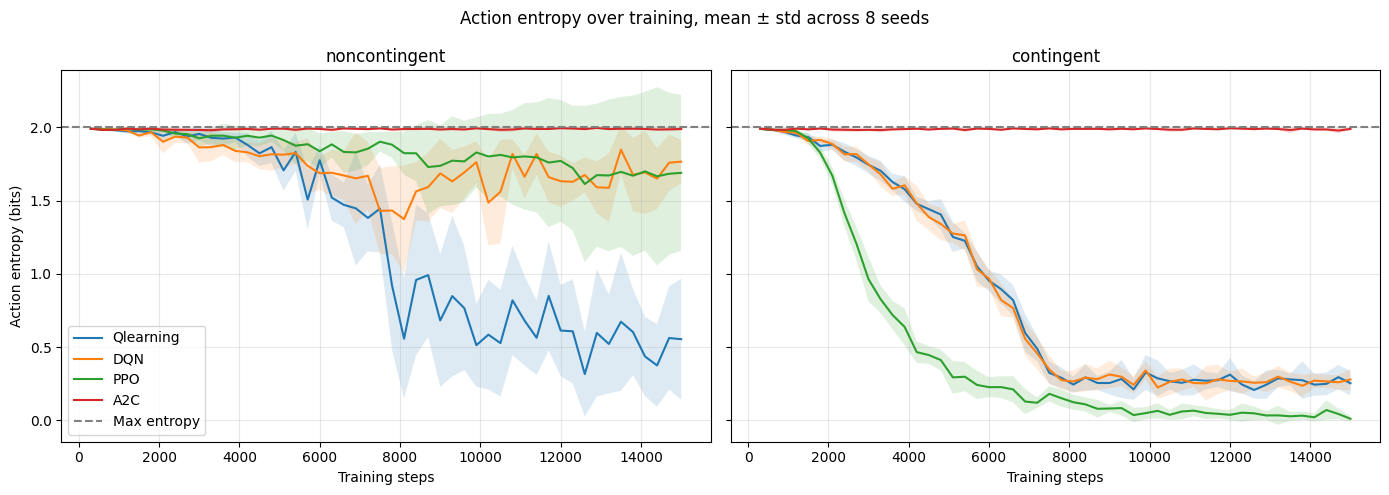

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for algo in ALGOS:
    for ax, condition in zip(axes, CONDITIONS):
        ts, mean, std = entropy_matrix(results_A[(algo, condition)])
        ax.plot(ts, mean, label=algo)
        ax.fill_between(ts, mean - std, mean + std, alpha=0.15)

for ax, condition in zip(axes, CONDITIONS):
    ax.axhline(np.log2(N_ACTIONS), color="gray", linestyle="--", label="Max entropy")
    ax.set_title(f"{condition}")
    ax.set_xlabel("Training steps")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Action entropy (bits)")
axes[0].legend()
fig.suptitle(f"Action entropy over training, mean \u00b1 std across {N_SEEDS} seeds")
plt.tight_layout()
plt.show()

In [15]:
rows = []
for algo in ALGOS:
    for condition in CONDITIONS:
        s = summarize(results_A[(algo, condition)])
        rows.append({
            "Algorithm": algo, "Condition": condition,
            "Final Entropy": f"{s['final_entropy_mean']:.2f} \u00b1 {s['final_entropy_std']:.2f}",
            "Ritual Strength": f"{s['ritual_strength_mean']:.2f} \u00b1 {s['ritual_strength_std']:.2f}",
            "Ritual Streak": f"{s['ritual_streak_mean']:.1f} \u00b1 {s['ritual_streak_std']:.1f}",
        })
df_A = pd.DataFrame(rows)
df_A

,Algorithm,Condition,Final Entropy,Ritual Strength,Ritual Streak
0,Qlearning,noncontingent,0.51 ± 0.12,0.83 ± 0.16,90.2 ± 22.4
1,Qlearning,contingent,0.26 ± 0.04,1.00 ± 0.00,11764.1 ± 29.8
2,DQN,noncontingent,1.71 ± 0.13,0.42 ± 0.09,14.2 ± 2.6
3,DQN,contingent,0.26 ± 0.02,1.00 ± 0.00,11778.2 ± 54.2
4,PPO,noncontingent,1.68 ± 0.56,0.50 ± 0.18,12.8 ± 13.0
5,PPO,contingent,0.04 ± 0.02,1.00 ± 0.00,13106.8 ± 44.9
6,A2C,noncontingent,1.99 ± 0.00,0.36 ± 0.05,6.5 ± 0.9
7,A2C,contingent,1.99 ± 0.01,1.00 ± 0.00,3860.4 ± 76.8


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
print("=== Tier A statistical tests ===\n")

print("Noncontingent vs. contingent, per algorithm (is the 'ritual' as strong as real learning?):")
for algo in ALGOS:
    s_nc = summarize(results_A[(algo, "noncontingent")])
    s_c = summarize(results_A[(algo, "contingent")])
    print(f" {algo}:")
    compare_two(s_nc["final_entropy_vals"], s_c["final_entropy_vals"],
                "noncontingent", "contingent", "final_entropy", tier="A")

print("\nAcross algorithms, noncontingent condition only (is superstition algorithm-dependent?):")
final_ent_by_algo = [summarize(results_A[(a, "noncontingent")])["final_entropy_vals"] for a in ALGOS]
compare_many(final_ent_by_algo, ALGOS, "final_entropy", tier="A")

ritual_streak_by_algo = [summarize(results_A[(a, "noncontingent")])["ritual_streak_vals"] for a in ALGOS]
compare_many(ritual_streak_by_algo, ALGOS, "ritual_streak", tier="A")

=== Tier A statistical tests ===

Noncontingent vs. contingent, per algorithm (is the 'ritual' as strong as real learning?):
 Qlearning:
  final_entropy | noncontingent vs contingent: Mann-Whitney p=0.0002 (uncorrected), Cohen's d=2.49, diff=0.243 [95% CI 0.157, 0.333]
 DQN:
  final_entropy | noncontingent vs contingent: Mann-Whitney p=0.0002 (uncorrected), Cohen's d=14.13, diff=1.446 [95% CI 1.346, 1.530]
 PPO:
  final_entropy | noncontingent vs contingent: Mann-Whitney p=0.0009 (uncorrected), Cohen's d=3.92, diff=1.646 [95% CI 1.225, 1.933]
 A2C:
  final_entropy | noncontingent vs contingent: Mann-Whitney p=0.6454 (uncorrected), Cohen's d=0.34, diff=0.002 [95% CI -0.003, 0.007]

Across algorithms, noncontingent condition only (is superstition algorithm-dependent?):
  final_entropy | Kruskal-Wallis across ['Qlearning', 'DQN', 'PPO', 'A2C']: p=0.0000 (uncorrected), epsilon^2=0.769
  ritual_streak | Kruskal-Wallis across ['Qlearning', 'DQN', 'PPO', 'A2C']: p=0.0000 (uncorrected), epsilo

(np.float64(1.1149030346907578e-05), 0.8098598044641212)

## Tier B — Reward Schedule Sensitivity

Does the *type* of noncontingent schedule (fixed / variable / random interval)
change how strongly a ritual forms? Tested on Q-learning and PPO (the pilot's two
core algorithms) to keep runtime manageable.

In [17]:
SCHEDULES = ["fixed", "variable", "random"]
TIER_B_ALGOS = ["Qlearning", "PPO"]

results_B = {}
for algo in TIER_B_ALGOS:
    for sched in SCHEDULES:
        results_B[(algo, sched)] = run_multiseed(
            algo, n_seeds=N_SEEDS, reward_mode="noncontingent",
            schedule_type=sched, curiosity_bonus=False, total_steps=TOTAL_STEPS
        )
        print(f"Done: {algo:>10s} / {sched}")

Done:  Qlearning / fixed
Done:  Qlearning / variable
Done:  Qlearning / random
Done:        PPO / fixed
Done:        PPO / variable
Done:        PPO / random


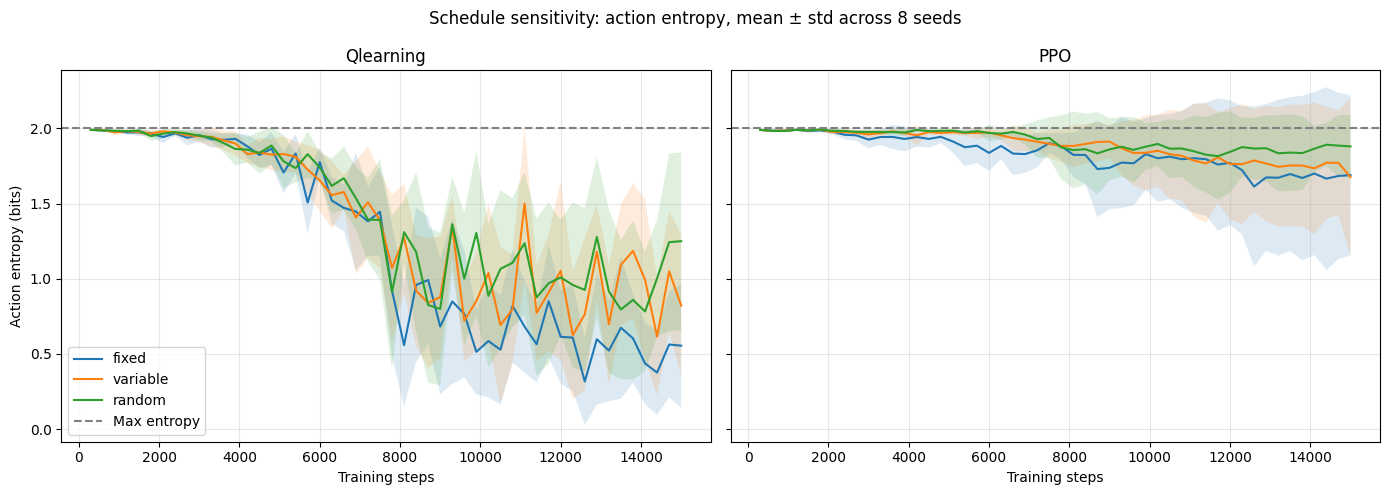

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, algo in zip(axes, TIER_B_ALGOS):
    for sched in SCHEDULES:
        ts, mean, std = entropy_matrix(results_B[(algo, sched)])
        ax.plot(ts, mean, label=sched)
        ax.fill_between(ts, mean - std, mean + std, alpha=0.15)
    ax.axhline(np.log2(N_ACTIONS), color="gray", linestyle="--", label="Max entropy")
    ax.set_title(algo)
    ax.set_xlabel("Training steps")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Action entropy (bits)")
axes[0].legend()
fig.suptitle(f"Schedule sensitivity: action entropy, mean \u00b1 std across {N_SEEDS} seeds")
plt.tight_layout()
plt.show()

In [19]:
rows = []
for algo in TIER_B_ALGOS:
    for sched in SCHEDULES:
        s = summarize(results_B[(algo, sched)])
        rows.append({
            "Algorithm": algo, "Schedule": sched,
            "Final Entropy": f"{s['final_entropy_mean']:.2f} \u00b1 {s['final_entropy_std']:.2f}",
            "Ritual Strength": f"{s['ritual_strength_mean']:.2f} \u00b1 {s['ritual_strength_std']:.2f}",
            "Ritual Streak": f"{s['ritual_streak_mean']:.1f} \u00b1 {s['ritual_streak_std']:.1f}",
        })
df_B = pd.DataFrame(rows)
df_B

,Algorithm,Schedule,Final Entropy,Ritual Strength,Ritual Streak
0,Qlearning,fixed,0.51 ± 0.12,0.83 ± 0.16,90.2 ± 22.4
1,Qlearning,variable,0.93 ± 0.12,0.73 ± 0.18,68.8 ± 17.0
2,Qlearning,random,1.03 ± 0.19,0.61 ± 0.20,55.5 ± 15.9
3,PPO,fixed,1.68 ± 0.56,0.50 ± 0.18,12.8 ± 13.0
4,PPO,variable,1.74 ± 0.42,0.44 ± 0.15,7.8 ± 5.1
5,PPO,random,1.87 ± 0.18,0.41 ± 0.12,7.6 ± 2.2


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
print("=== Tier B statistical tests: does schedule type matter? ===\n")
for algo in TIER_B_ALGOS:
    print(f"{algo}:")
    vals = [summarize(results_B[(algo, s)])["final_entropy_vals"] for s in SCHEDULES]
    compare_many(vals, SCHEDULES, "final_entropy", tier="B")
    vals_rs = [summarize(results_B[(algo, s)])["ritual_strength_vals"] for s in SCHEDULES]
    compare_many(vals_rs, SCHEDULES, "ritual_strength", tier="B")
    print()

=== Tier B statistical tests: does schedule type matter? ===

Qlearning:
  final_entropy | Kruskal-Wallis across ['fixed', 'variable', 'random']: p=0.0004 (uncorrected), epsilon^2=0.655
  ritual_strength | Kruskal-Wallis across ['fixed', 'variable', 'random']: p=0.0995 (uncorrected), epsilon^2=0.125

PPO:
  final_entropy | Kruskal-Wallis across ['fixed', 'variable', 'random']: p=0.5813 (uncorrected), epsilon^2=-0.044
  ritual_strength | Kruskal-Wallis across ['fixed', 'variable', 'random']: p=0.1502 (uncorrected), epsilon^2=0.085



## Tier C — Curiosity-Driven Exploration (Moderator Test)

Does adding a count-based exploration bonus dilute the ritual (broader coverage,
per the "Noisy TV" chapter's mitigation angle) or compound it (a second source of
spurious reward)? Tested on Q-learning and PPO, fixed-interval noncontingent
condition only.

In [21]:
results_C = {}
for algo in TIER_B_ALGOS:
    for curiosity in [False, True]:
        results_C[(algo, curiosity)] = run_multiseed(
            algo, n_seeds=N_SEEDS, reward_mode="noncontingent",
            schedule_type="fixed", curiosity_bonus=curiosity, total_steps=TOTAL_STEPS
        )
        label = "curiosity ON" if curiosity else "curiosity OFF"
        print(f"Done: {algo:>10s} / {label}")

Done:  Qlearning / curiosity OFF
Done:  Qlearning / curiosity ON
Done:        PPO / curiosity OFF
Done:        PPO / curiosity ON


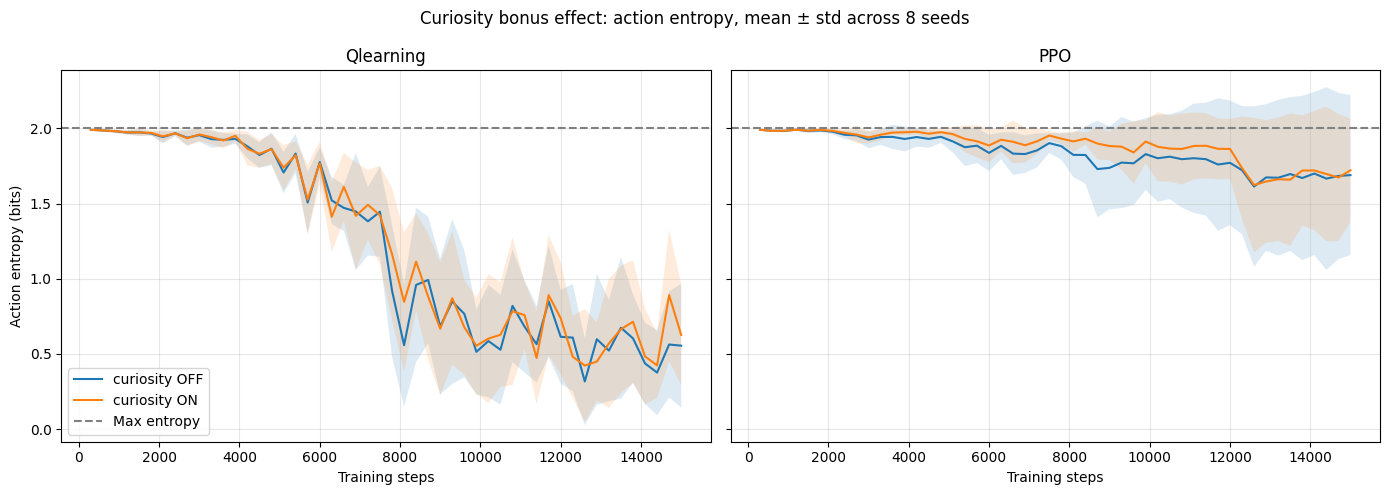

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, algo in zip(axes, TIER_B_ALGOS):
    for curiosity, label in [(False, "curiosity OFF"), (True, "curiosity ON")]:
        ts, mean, std = entropy_matrix(results_C[(algo, curiosity)])
        ax.plot(ts, mean, label=label)
        ax.fill_between(ts, mean - std, mean + std, alpha=0.15)
    ax.axhline(np.log2(N_ACTIONS), color="gray", linestyle="--", label="Max entropy")
    ax.set_title(algo)
    ax.set_xlabel("Training steps")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Action entropy (bits)")
axes[0].legend()
fig.suptitle(f"Curiosity bonus effect: action entropy, mean \u00b1 std across {N_SEEDS} seeds")
plt.tight_layout()
plt.show()

In [23]:
rows = []
for algo in TIER_B_ALGOS:
    for curiosity in [False, True]:
        s = summarize(results_C[(algo, curiosity)])
        rows.append({
            "Algorithm": algo, "Curiosity": "ON" if curiosity else "OFF",
            "Final Entropy": f"{s['final_entropy_mean']:.2f} \u00b1 {s['final_entropy_std']:.2f}",
            "Ritual Strength": f"{s['ritual_strength_mean']:.2f} \u00b1 {s['ritual_strength_std']:.2f}",
            "Ritual Streak": f"{s['ritual_streak_mean']:.1f} \u00b1 {s['ritual_streak_std']:.1f}",
        })
df_C = pd.DataFrame(rows)
df_C

,Algorithm,Curiosity,Final Entropy,Ritual Strength,Ritual Streak
0,Qlearning,OFF,0.51 ± 0.12,0.83 ± 0.16,90.2 ± 22.4
1,Qlearning,ON,0.63 ± 0.10,0.84 ± 0.15,80.2 ± 19.1
2,PPO,OFF,1.68 ± 0.56,0.50 ± 0.18,12.8 ± 13.0
3,PPO,ON,1.71 ± 0.39,0.48 ± 0.12,11.0 ± 7.2


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [24]:
print("=== Tier C statistical tests: does curiosity change the ritual? ===\n")
for algo in TIER_B_ALGOS:
    s_off = summarize(results_C[(algo, False)])
    s_on = summarize(results_C[(algo, True)])
    print(f"{algo}:")
    compare_two(s_off["final_entropy_vals"], s_on["final_entropy_vals"],
                "curiosity OFF", "curiosity ON", "final_entropy", tier="C")
    compare_two(s_off["ritual_strength_vals"], s_on["ritual_strength_vals"],
                "curiosity OFF", "curiosity ON", "ritual_strength", tier="C")
    print()

=== Tier C statistical tests: does curiosity change the ritual? ===

Qlearning:
  final_entropy | curiosity OFF vs curiosity ON: Mann-Whitney p=0.0499 (uncorrected), Cohen's d=-1.02, diff=-0.121 [95% CI -0.226, -0.011]
  ritual_strength | curiosity OFF vs curiosity ON: Mann-Whitney p=1.0000 (uncorrected), Cohen's d=-0.07, diff=-0.013 [95% CI -0.167, 0.138]

PPO:
  final_entropy | curiosity OFF vs curiosity ON: Mann-Whitney p=0.7984 (uncorrected), Cohen's d=-0.05, diff=-0.025 [95% CI -0.529, 0.416]
  ritual_strength | curiosity OFF vs curiosity ON: Mann-Whitney p=1.0000 (uncorrected), Cohen's d=0.10, diff=0.017 [95% CI -0.121, 0.179]



> **Before submission -- pre-registration disclosure (recommended #4):**
> If the Tier B (schedule) and Tier C (curiosity) hypotheses were decided *before*
> you saw Tier A's results, say so explicitly in the paper's Methods section --
> it's a credibility point that costs nothing, since it's already true or it
> isn't. This notebook can't confirm the chronology for you, so don't add the
> sentence unless you know it's accurate.
>
> Suggested wording, if true: *"The schedule-type manipulation (Tier B) and the
> curiosity-bonus manipulation (Tier C) were specified as part of the original
> experimental design, prior to running the Tier A algorithm comparison."*
>
> If the ordering was actually the other way around (e.g. Tier B's schedule
> comparison was added *because* Tier A's Q-learning result looked interesting),
> say that instead -- an honest "this follow-up was motivated by Tier A" is also
> a perfectly fine and common thing to disclose, it's just a different sentence.


## 6. Tier D — Interval-Length Sensitivity Check (I = 5, 10, 20)

**Recommended #1.** Tier B's central claim is that Q-learning's fixed-interval
ritual is stronger than its variable/random-interval ritual because a *fixed
temporal phase* lets a bootstrapped update lock onto it — not because
noncontingency alone is sufficient. If that mechanism is right, and not an
artifact of the specific interval length `I=10` used everywhere else in this
study, the same qualitative pattern (entropy collapse, high ritual strength)
should hold at other interval lengths too.

This tier reruns Q-learning under the **fixed-interval** schedule at `I=5` and
`I=20`, and reuses the existing `I=10` result from Tier B directly (same
training code, same seeds, same everything else) rather than rerunning it, so
the three-way comparison is exactly apples-to-apples.

Restricted to **Q-learning only** (the algorithm with the clear schedule-
sensitivity effect in Tier B) to keep runtime manageable — PPO showed
essentially no schedule sensitivity in Tier B, so an interval sweep on PPO is a
lower-priority follow-up rather than a check on this study's central claim.

**Statistical note:** these tests are logged under their own family
(`interval_sensitivity_entropy` / `interval_sensitivity_ritual`), separate from
the Tier A-C confirmatory families, since this is a post-hoc robustness check
on a single parameter added after seeing Tier B's result, not part of the
original design — see the pre-registration note above and Section 7 below.


In [25]:
INTERVAL_SWEEP = [5, INTERVAL, 20]  # INTERVAL == 10; included via the Tier B reuse below

results_D = {INTERVAL: results_B[("Qlearning", "fixed")]}  # reuse Tier B's I=10 run verbatim
for I_val in [5, 20]:
    results_D[I_val] = run_multiseed(
        "Qlearning", n_seeds=N_SEEDS, reward_mode="noncontingent",
        schedule_type="fixed", curiosity_bonus=False, total_steps=TOTAL_STEPS,
        interval=I_val,
    )
    print(f"Done: Qlearning / I={I_val}")


Done: Qlearning / I=5
Done: Qlearning / I=20


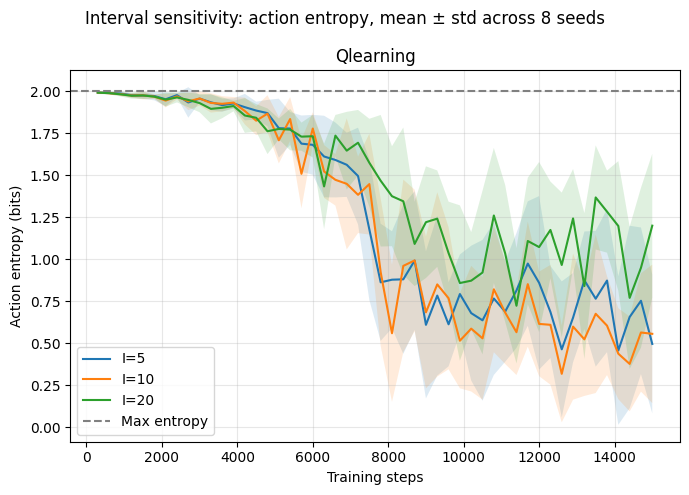

In [26]:
fig, ax = plt.subplots(figsize=(7, 5))
for I_val in INTERVAL_SWEEP:
    ts, mean, std = entropy_matrix(results_D[I_val])
    ax.plot(ts, mean, label=f"I={I_val}")
    ax.fill_between(ts, mean - std, mean + std, alpha=0.15)
ax.axhline(np.log2(N_ACTIONS), color="gray", linestyle="--", label="Max entropy")
ax.set_title("Qlearning")
ax.set_xlabel("Training steps")
ax.set_ylabel("Action entropy (bits)")
ax.grid(alpha=0.3)
ax.legend()
fig.suptitle(f"Interval sensitivity: action entropy, mean \u00b1 std across {N_SEEDS} seeds")
plt.tight_layout()
plt.show()


In [27]:
rows = []
for I_val in INTERVAL_SWEEP:
    s = summarize(results_D[I_val])
    rows.append({
        "Interval (I)": I_val,
        "Final Entropy": f"{s['final_entropy_mean']:.2f} \u00b1 {s['final_entropy_std']:.2f}",
        "Ritual Strength": f"{s['ritual_strength_mean']:.2f} \u00b1 {s['ritual_strength_std']:.2f}",
        "Ritual Streak": f"{s['ritual_streak_mean']:.1f} \u00b1 {s['ritual_streak_std']:.1f}",
    })
df_D = pd.DataFrame(rows)
df_D


,Interval (I),Final Entropy,Ritual Strength,Ritual Streak
0,5,0.65 ± 0.15,0.95 ± 0.10,120.0 ± 29.9
1,10,0.51 ± 0.12,0.83 ± 0.16,90.2 ± 22.4
2,20,1.08 ± 0.20,0.60 ± 0.16,23.5 ± 3.5


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [28]:
print("=== Tier D statistical tests: does interval length change the ritual? ===\n")
print("Qlearning:")
vals = [summarize(results_D[I_val])["final_entropy_vals"] for I_val in INTERVAL_SWEEP]
compare_many(vals, [f"I={v}" for v in INTERVAL_SWEEP], "final_entropy",
             family="interval_sensitivity_entropy", tier="D")
vals_rs = [summarize(results_D[I_val])["ritual_strength_vals"] for I_val in INTERVAL_SWEEP]
compare_many(vals_rs, [f"I={v}" for v in INTERVAL_SWEEP], "ritual_strength",
             family="interval_sensitivity_ritual", tier="D")


=== Tier D statistical tests: does interval length change the ritual? ===

Qlearning:
  final_entropy | Kruskal-Wallis across ['I=5', 'I=10', 'I=20']: p=0.0006 (uncorrected), epsilon^2=0.616
  ritual_strength | Kruskal-Wallis across ['I=5', 'I=10', 'I=20']: p=0.0018 (uncorrected), epsilon^2=0.507


(np.float64(0.001797683883128138), 0.5067863023071828)

## 7. Multiple-Comparisons Correction

**Must-fix #1.** Every test run above (Tiers A-D) was logged to `TEST_LOG` as it
happened, tagged with a `family`: `final_entropy`, `ritual_strength`, and
`ritual_streak` for the confirmatory design (Tiers A-C), plus
`interval_sensitivity_entropy` / `interval_sensitivity_ritual` for the Tier D
post-hoc check.

Correction is **Holm-Bonferroni**, applied *within* each family rather than
across all tests globally. Family membership follows the metric/question being
tested, not the tier — a claim about entropy and a claim about ritual strength
are different scientific questions, so a ritual-strength test elsewhere in the
study shouldn't inflate the correction burden on an entropy test, or vice
versa. Holm-Bonferroni is used instead of plain Bonferroni because it's
uniformly more powerful while still controlling the family-wise error rate
exactly (no assumption of independence between tests is needed either way).

The cell below prints every test with both its raw and corrected p-value; the
one after it isolates any test whose significance verdict *changes* under
correction, since those are the sentences in Results/Discussion that need to
be rewritten before submission, not just re-numbered.


In [29]:
correction_df = apply_family_correction(TEST_LOG, alpha=ALPHA)

display_cols = ["tier", "family", "comparison", "metric",
                 "p_raw", "p_corrected", "significant_raw", "significant_corrected"]
correction_df_display = correction_df[display_cols].sort_values(["family", "tier"]).reset_index(drop=True)
correction_df_display


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,tier,family,comparison,metric,p_raw,p_corrected,significant_raw,significant_corrected
0,A,final_entropy,noncontingent vs contingent,final_entropy,0.000155,0.001243,True,True
1,A,final_entropy,noncontingent vs contingent,final_entropy,0.000155,0.001243,True,True
2,A,final_entropy,noncontingent vs contingent,final_entropy,0.000907,0.004534,True,True
3,A,final_entropy,noncontingent vs contingent,final_entropy,0.645377,1.000000,False,False
4,A,final_entropy,Qlearning vs DQN vs PPO vs A2C,final_entropy,0.000019,0.000173,True,True
5,B,final_entropy,fixed vs variable vs random,final_entropy,0.000377,0.002264,True,True
6,B,final_entropy,fixed vs variable vs random,final_entropy,0.581293,1.000000,False,False
7,C,final_entropy,curiosity OFF vs curiosity ON,final_entropy,0.049883,0.199534,True,False
8,C,final_entropy,curiosity OFF vs curiosity ON,final_entropy,0.798446,1.000000,False,False
9,D,interval_sensitivity_entropy,I=5 vs I=10 vs I=20,final_entropy,0.000569,0.000569,True,True


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [30]:
flipped = correction_df[correction_df["significant_raw"] & ~correction_df["significant_corrected"]]

print(f"{len(flipped)} test(s) lose significance after Holm-Bonferroni correction "
      f"(alpha={ALPHA}):\n")
if len(flipped) > 0:
    print(flipped[display_cols].to_string(index=False))
    print("\nThese specific claims need softer language (or removal) in Results/"
          "Discussion -- e.g. \'p=0.0499\' becoming non-significant after correction "
          "means a sentence currently claiming a significant effect there is now "
          "overstated.")
else:
    print("None -- every test that was significant at alpha=0.05 before correction "
          "remains significant after Holm-Bonferroni. (Still confirm this holds once "
          "you rerun with real data; this is exactly the kind of result you want to "
          "double-check rather than assume.)")


1 test(s) lose significance after Holm-Bonferroni correction (alpha=0.05):

tier        family                    comparison        metric    p_raw  p_corrected  significant_raw  significant_corrected
   C final_entropy curiosity OFF vs curiosity ON final_entropy 0.049883     0.199534             True                  False

These specific claims need softer language (or removal) in Results/Discussion -- e.g. 'p=0.0499' becoming non-significant after correction means a sentence currently claiming a significant effect there is now overstated.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 8. Raw Per-Seed Data Export

**Must-fix #4 (feeds the CIs above) and recommended #3.** Every number in
Tables 2-4 (and df_D above) is a mean +/- SD over `N_SEEDS` seeds; this cell
dumps the underlying **per-seed** values in long format, plus the complete
entropy/ritual logs for every single run, so a reviewer (or you, in six
months) never has to regenerate anything from scratch to check a number.

Two files get written to `RESULTS_DIR`:
- **`per_seed_summary.csv`** — one row per (tier, algorithm, condition, seed) —
  this *is* the supplementary per-seed table; attach it to the paper as-is or
  reformat it into the appendix.
- **`raw_logs.pkl`** — the full `entropy_log` / `ritual_log` for every run, for
  anyone who wants to replot the trajectories or compute a different statistic
  entirely.
- **`statistical_tests_corrected.csv`** — the corrected-p-value table from
  Section 7, for the same reason.


In [31]:
import pickle
from pathlib import Path

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)


def _tier_to_rows(results_dict, tier_name, key_names):
    """results_dict: {key (tuple or scalar): [per-seed result dicts]}.
    key_names labels the fields of that key for the output columns."""
    rows = []
    for key, seed_results in results_dict.items():
        key_tuple = key if isinstance(key, tuple) else (key,)
        for seed_idx, r in enumerate(seed_results):
            final_e = float(final_entropy_vals([r])[0])
            rm = ritual_metrics(r["ritual_log"])
            row = {
                "tier": tier_name, "seed": seed_idx,
                "final_entropy": final_e,
                "ritual_strength": rm["ritual_strength"],
                "ritual_streak": rm["ritual_streak"],
            }
            row.update(dict(zip(key_names, key_tuple)))
            rows.append(row)
    return rows


all_rows = []
all_rows += _tier_to_rows(results_A, "A", ["algorithm", "condition"])
all_rows += _tier_to_rows(results_B, "B", ["algorithm", "schedule"])
all_rows += _tier_to_rows(results_C, "C", ["algorithm", "curiosity"])
all_rows += _tier_to_rows(results_D, "D", ["interval"])

per_seed_df = pd.DataFrame(all_rows)
per_seed_df.to_csv(RESULTS_DIR / "per_seed_summary.csv", index=False)

with open(RESULTS_DIR / "raw_logs.pkl", "wb") as f:
    pickle.dump({"A": results_A, "B": results_B, "C": results_C, "D": results_D}, f)

correction_df.to_csv(RESULTS_DIR / "statistical_tests_corrected.csv", index=False)
dqn_hparam_table.to_csv(RESULTS_DIR / "dqn_hyperparameter_overrides.csv", index=False)

print(f"Wrote {len(per_seed_df)} per-seed rows to {RESULTS_DIR / 'per_seed_summary.csv'}")
print(f"Wrote full logs to {RESULTS_DIR / 'raw_logs.pkl'}")
print(f"Wrote corrected test table to {RESULTS_DIR / 'statistical_tests_corrected.csv'}")
print(f"Wrote DQN hyperparameter table to {RESULTS_DIR / 'dqn_hyperparameter_overrides.csv'}")
per_seed_df.head()


Wrote 168 per-seed rows to results/per_seed_summary.csv
Wrote full logs to results/raw_logs.pkl
Wrote corrected test table to results/statistical_tests_corrected.csv
Wrote DQN hyperparameter table to results/dqn_hyperparameter_overrides.csv


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,tier,seed,final_entropy,ritual_strength,ritual_streak,algorithm,condition,schedule,curiosity,interval
0,A,0,0.441464,0.900000,71,Qlearning,noncontingent,NaN,NaN,NaN
1,A,1,0.543839,0.866667,111,Qlearning,noncontingent,NaN,NaN,NaN
2,A,2,0.345883,0.700000,75,Qlearning,noncontingent,NaN,NaN,NaN
3,A,3,0.393092,0.966667,80,Qlearning,noncontingent,NaN,NaN,NaN
4,A,4,0.402461,1.000000,80,Qlearning,noncontingent,NaN,NaN,NaN


## 9. Packaging for the Public Repository

**Must-fix #3.** "Available on reasonable request" is weaker than it needs to
be, and costs nothing to fix now rather than when a reviewer asks. This cell
zips everything a reviewer needs to reproduce the study — the environment and
training code already live in this notebook, and `results/` holds the data
just exported above.

After running this cell:
1. `git init` in a fresh folder, add this notebook, `results/`, and a short
   `README.md` describing the environment, the four algorithms, the three
   schedules, and the two tiers of moderators (schedule, curiosity).
2. Push to GitHub.
3. Go to **https://zenodo.org/account/settings/github/**, flip the switch for
   the new repo, then cut a GitHub release (a tagged version, e.g. `v1.0`) —
   Zenodo mints a DOI automatically the moment the release is published.
4. Replace the paper's Data Availability sentence with the DOI link (a DOI is
   preferred over a bare GitHub link since it's permanent and citable).


In [32]:
import shutil

archive_path = shutil.make_archive("superstitious_rl_release", "zip",
                                    root_dir=".", base_dir="results")
print(f"Wrote {archive_path} -- upload this alongside the notebook when you "
      f"push to GitHub (or just push the results/ folder directly, same thing).")


Wrote /content/superstitious_rl_release.zip -- upload this alongside the notebook when you push to GitHub (or just push the results/ folder directly, same thing).


## Summary of What This Notebook Does and Does Not Establish

**What it supports, with statistics behind it:**
- Whether noncontingent (fixed-interval) reward produces an entropy drop
  statistically indistinguishable from, or significantly different from, a real
  learnable contingency — per algorithm (Tier A).
- Whether that effect differs significantly *across* algorithms (Tier A
  Kruskal-Wallis test) — i.e., whether "superstition" is algorithm-dependent.
- Whether the *type* of noncontingent schedule (fixed / variable / random
  interval) changes the strength of the effect (Tier B) — directly testing the
  psychology literature's schedule-sensitivity claim (Staddon & Simmelhag 1971).
- Whether a simple exploration bonus dilutes or compounds the effect (Tier C).

**What it still does not establish (be upfront about these in a paper):**
- Everything here is in one abstract, single-state toy environment. Generalization
  to richer/spatial environments (e.g. gridworlds, Atari-style tasks) is untested.
- The curiosity module is a count-based proxy, not true prediction-error curiosity
  (ICM/RND) — those need a genuinely varying observation to be meaningful.
- Hyperparameters (learning rates, network sizes, `interval` value, episode length)
  were fixed at reasonable defaults, not swept — a full sensitivity analysis over
  these would further strengthen robustness claims.
- All experiments use the same random-seed range (0 to N_SEEDS-1) across
  conditions; for a submission, document your exact seed list and consider
  increasing `N_SEEDS` to 15-30 for tighter confidence intervals.

**What this revision adds on top of the above:**
- Every Mann-Whitney and Kruskal-Wallis test across Tiers A-D is now
  Holm-Bonferroni corrected within its metric family (Section 7) — check
  `correction_df` / the "flipped" cell before trusting any p-value quoted in
  the paper text, since a couple of the borderline ones (Tier B ritual-strength
  schedule comparison, Tier C Q-learning curiosity effect) were close enough to
  0.05 uncorrected that correction may change their verdict.
- Bootstrap 95% CIs on every group-difference (alongside p and Cohen's d) and
  epsilon-squared on every Kruskal-Wallis test, both logged automatically by
  the redefined `compare_two` / `compare_many`.
- A new Tier D interval-length sensitivity check (I=5/10/20) on Q-learning,
  addressing whether the fixed-interval phase-locking story from Tier B is
  specific to I=10 or genuinely about temporal-phase-locking.
- A `DQN_OVERRIDES`-driven hyperparameter table with SB3 defaults and a
  rationale for each override, sourced from the same dict the training code
  actually uses.
- A full per-seed CSV export, pickled raw logs, and a packaging step for a
  public GitHub + Zenodo release, replacing "available on request."

**Still outstanding, and not something this notebook can do for you:**
- The pre-registration disclosure sentence (see the markdown cell right after
  Tier C) — only add it if the chronology it describes is actually true.
- Actually creating the GitHub repo and Zenodo DOI (Section 9 packages the
  data; pushing and releasing it needs your GitHub account).
- Updating the paper's prose/tables to reflect whatever `correction_df` says
  once you run this for real — in particular, rewording any claim whose
  significance verdict flips under correction.
